In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('Monthly champagne Sales.csv')

In [4]:
df.head()

,Month,Perrin Freres monthly champagne sales millions
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


In [10]:
df.tail()

,Months,Sales
100,1972-05,4618
101,1972-06,5312
102,1972-07,4298
103,1972-08,1413
104,1972-09,5877


In [11]:
df.columns = ["Month", "Sales"]

In [15]:
df.dtypes

Month    object
Sales     int64
dtype: object

In [17]:
df['Month'] = pd.to_datetime(df['Month'])

In [18]:
df.head()

,Month,Sales
0,1964-01-01,2815
1,1964-02-01,2672
2,1964-03-01,2755
3,1964-04-01,2721
4,1964-05-01,2946


In [19]:
df.dtypes

Month    datetime64[ns]
Sales             int64
dtype: object

In [25]:
df1= df.set_index('Month')

In [22]:
df.describe()

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


In [26]:
df1.head()

,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


<AxesSubplot: xlabel='Month'>

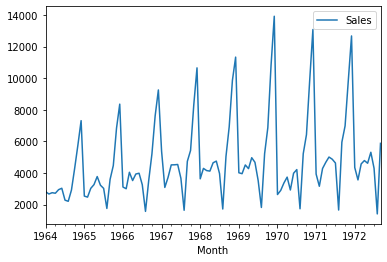

In [27]:
df1.plot()

In [28]:
#Testing for stationarity
from statsmodels.tsa.stattools import adfuller


In [33]:
test_result = adfuller(df1['Sales'])

In [30]:
test_result

(-1.8335930563276264,
 0.36391577166024336,
 11,
 93,
 {'1%': -3.502704609582561,
  '5%': -2.8931578098779522,
  '10%': -2.583636712914788},
 1478.4633060594724)

In [31]:
# Ho - Data is Non-Stationary
# H1 - Data is Stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")
    

In [34]:
adfuller_test(df1['Sales'])

ADF Test Statistic : -1.8335930563276264
p-value : 0.36391577166024336
#Lags Used : 11
Number of Observations Used : 93
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [35]:
#Differencing
df1['Sales First Difference'] = df1['Sales'] - df1['Sales'].shift(1)
df1.head()

,Sales,Sales First Difference
Month,,
1964-01-01,2815,NaN
1964-02-01,2672,-143.0
1964-03-01,2755,83.0
1964-04-01,2721,-34.0
1964-05-01,2946,225.0


In [39]:
df1['Seasonal First Difference'] = df1['Sales'] - df1['Sales'].shift(12)
df1.tail()

,Sales,Sales First Difference,Seasonal First Difference
Month,,,
1972-05-01,4618,-170.0,-392.0
1972-06-01,5312,694.0,438.0
1972-07-01,4298,-1014.0,-335.0
1972-08-01,1413,-2885.0,-246.0
1972-09-01,5877,4464.0,-74.0


In [40]:
adfuller_test(df1['Sales First Difference'].dropna())

ADF Test Statistic : -7.189896448051044
p-value : 2.519620447386421e-10
#Lags Used : 11
Number of Observations Used : 92
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [41]:
adfuller_test(df1['Seasonal First Difference'].dropna())

ADF Test Statistic : -7.626619157213164
p-value : 2.060579696813685e-11
#Lags Used : 0
Number of Observations Used : 92
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<AxesSubplot: xlabel='Month'>

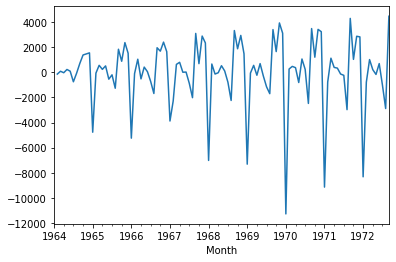

In [42]:
df1['Sales First Difference'].plot()

<AxesSubplot: xlabel='Month'>

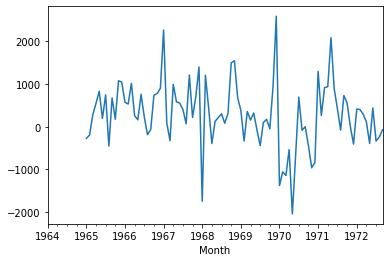

In [43]:
df1['Seasonal First Difference'].plot()

### Auto Regressive Model
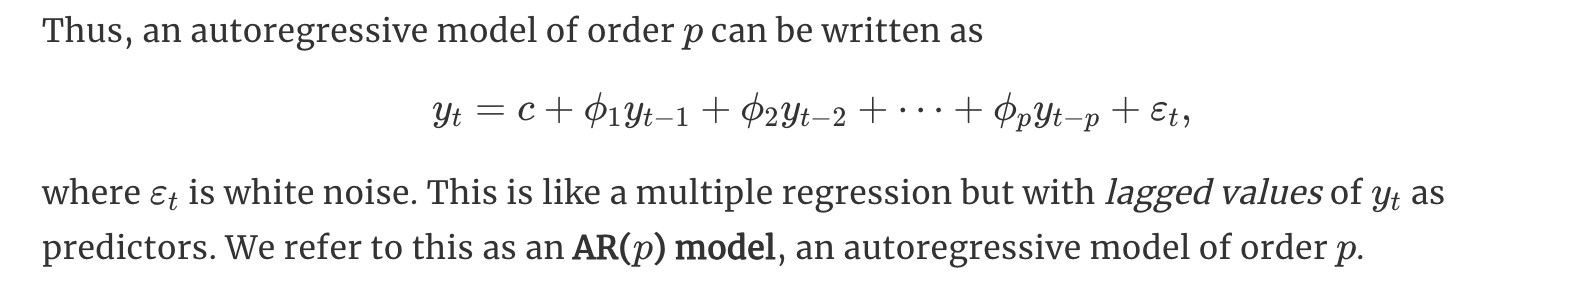

In [54]:
# to understand how many lagged values are related to Y then we need to plot Autocorrelation plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

### Final Thoughts on Autocorrelation and Partial Autocorrelation
- Identification of an AR model is often best done with the PACF.

  - For an AR model, the theoretical PACF “shuts off” past the order of the model. The phrase “shuts off” means that in theory the partial autocorrelations are equal to 0 beyond that point. Put another way, the number of non-zero partial autocorrelations gives the order of the AR model. By the “order of the model” we mean the most extreme lag of x that is used as a predictor.
- Identification of an MA model is often best done with the ACF rather than the PACF.

  - For an MA model, the theoretical PACF does not shut off, but instead tapers toward 0 in some manner. A clearer pattern for an MA model is in the ACF. The ACF will have non-zero autocorrelations only at lags involved in the model.
- p,d,q p AR model lags d differencing q MA lags

/Users/sheetalsuwalka/opt/anaconda3/lib/python3.9/site-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


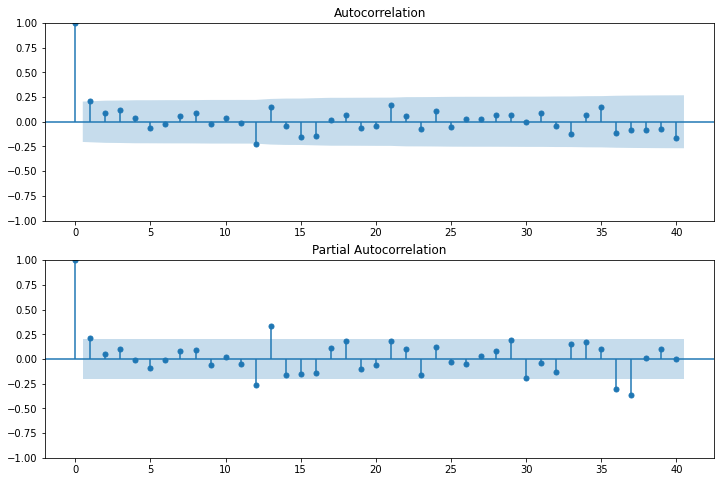

In [59]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df1['Seasonal First Difference'].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df1['Seasonal First Difference'].iloc[13:],lags=40,ax=ax2)

In [69]:
# From above graph of PACF we select values as 1 as after 1 lag the values are shuts off so we select value 1 for AR model
# From above graph of ACF we select values as 0 or 1 as there is exponentional decrease till 1 only, so we select value 0/1 for 
# MA model


In [66]:
# For Non Seasonal data
from statsmodels.tsa.arima.model import ARIMA

In [83]:
# p = 1 for AR model, d = 1 for sales differencing, and q = 0 or 1 for MA model
model = ARIMA(df1['Sales'], order = (1, 1, 1))
model_fit = model.fit()

/Users/sheetalsuwalka/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/sheetalsuwalka/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/sheetalsuwalka/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [84]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  105
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -952.814
Date:                Tue, 04 Jul 2023   AIC                           1911.627
Time:                        19:31:27   BIC                           1919.560
Sample:                    01-01-1964   HQIC                          1914.841
                         - 09-01-1972                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4545      0.114      3.999      0.000       0.232       0.677
ma.L1         -0.9666      0.056    -17.316      0.000      -1.076      -0.857
sigma2      5.226e+06   6.17e+05      8.473      0.000    4.02e+06    6.43e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.91   Jarque-Bera (JB):                 2.59
Prob(Q):                              0.34   Prob(JB):                         0.27
Heteroskedasticity (H):               3.40   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot: xlabel='Month'>

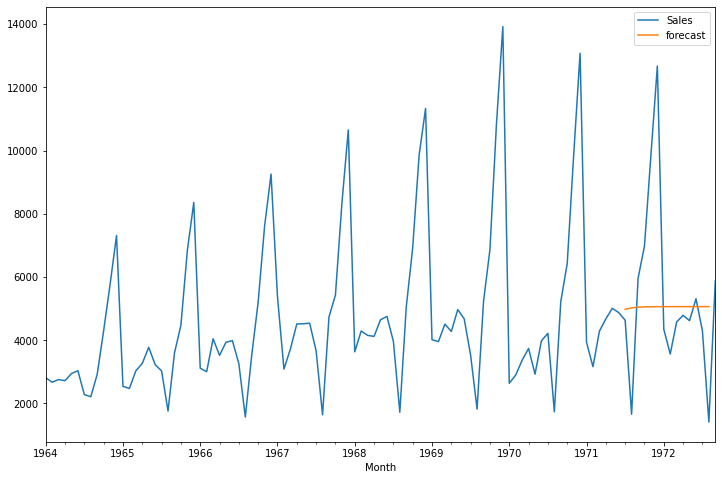

In [85]:
df1['forecast'] = model_fit.predict(start = 90, end = 103, dynamic = True)
df1[['Sales', 'forecast']].plot(figsize = (12,8))

### For ARIMA to work, timeseries should be stationary. Above we have used non-stationary

In [86]:
model = sm.tsa.statespace.SARIMAX(df1['Sales'], order = (1, 1, 1), seasonal_order = (1,1,1,12))
results = model.fit()

/Users/sheetalsuwalka/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/sheetalsuwalka/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.07295D+00    |proj g|=  4.80911D-02

At iterate    5    f=  7.04942D+00    |proj g|=  1.53381D-02

At iterate   10    f=  7.04713D+00    |proj g|=  2.99453D-04

At iterate   15    f=  7.04708D+00    |proj g|=  5.05914D-03

At iterate   20    f=  7.04413D+00    |proj g|=  1.18417D-02

At iterate   25    f=  7.03252D+00    |proj g|=  1.06319D-03

At iterate   30    f=  7.03240D+00    |proj g|=  5.51656D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nac

<AxesSubplot: xlabel='Month'>

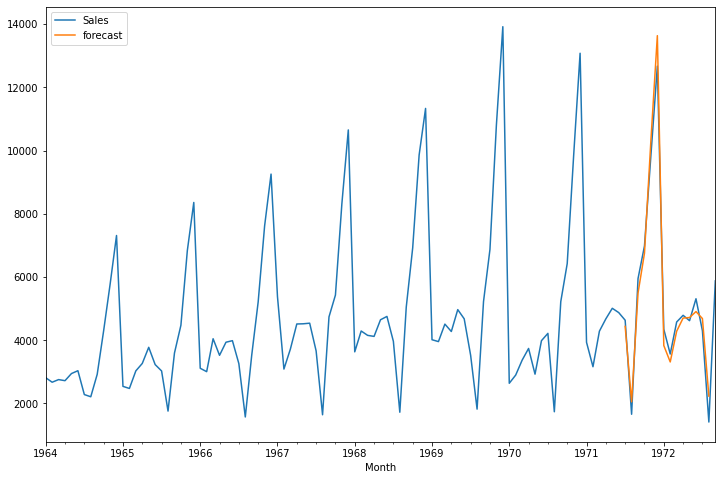

In [87]:
df1['forecast'] = results.predict(start = 90, end = 103, dynamic = True)
df1[['Sales', 'forecast']].plot(figsize = (12,8))

#### Future Prediction

In [91]:
from pandas.tseries.offsets import DateOffset
future_dates = [df1.index[-1] + DateOffset(months= x) for x in range(0,24)] 
future_dates

[Timestamp('1972-09-01 00:00:00'),
 Timestamp('1972-10-01 00:00:00'),
 Timestamp('1972-11-01 00:00:00'),
 Timestamp('1972-12-01 00:00:00'),
 Timestamp('1973-01-01 00:00:00'),
 Timestamp('1973-02-01 00:00:00'),
 Timestamp('1973-03-01 00:00:00'),
 Timestamp('1973-04-01 00:00:00'),
 Timestamp('1973-05-01 00:00:00'),
 Timestamp('1973-06-01 00:00:00'),
 Timestamp('1973-07-01 00:00:00'),
 Timestamp('1973-08-01 00:00:00'),
 Timestamp('1973-09-01 00:00:00'),
 Timestamp('1973-10-01 00:00:00'),
 Timestamp('1973-11-01 00:00:00'),
 Timestamp('1973-12-01 00:00:00'),
 Timestamp('1974-01-01 00:00:00'),
 Timestamp('1974-02-01 00:00:00'),
 Timestamp('1974-03-01 00:00:00'),
 Timestamp('1974-04-01 00:00:00'),
 Timestamp('1974-05-01 00:00:00'),
 Timestamp('1974-06-01 00:00:00'),
 Timestamp('1974-07-01 00:00:00'),
 Timestamp('1974-08-01 00:00:00')]

In [94]:
future_dataset_df = pd.DataFrame(index = future_dates[1:], columns = df1.columns)
future_dataset_df.head()

,Sales,Sales First Difference,Seasonal First Difference,forecast
1972-10-01,NaN,NaN,NaN,NaN
1972-11-01,NaN,NaN,NaN,NaN
1972-12-01,NaN,NaN,NaN,NaN
1973-01-01,NaN,NaN,NaN,NaN
1973-02-01,NaN,NaN,NaN,NaN


In [98]:
future_dataset_df.tail()

,Sales,Sales First Difference,Seasonal First Difference,forecast
1974-04-01,NaN,NaN,NaN,NaN
1974-05-01,NaN,NaN,NaN,NaN
1974-06-01,NaN,NaN,NaN,NaN
1974-07-01,NaN,NaN,NaN,NaN
1974-08-01,NaN,NaN,NaN,NaN


In [101]:
future_dataset_df.shape

(23, 4)

In [95]:
df1.tail()

,Sales,Sales First Difference,Seasonal First Difference,forecast
Month,,,,
1972-05-01,4618,-170.0,-392.0,4717.510043
1972-06-01,5312,694.0,438.0,4906.403556
1972-07-01,4298,-1014.0,-335.0,4685.435721
1972-08-01,1413,-2885.0,-246.0,2232.408155
1972-09-01,5877,4464.0,-74.0,NaN


In [3]:
future_df = pd.concat([df1, future_dataset_df])

NameError: name 'pd' is not defined

In [97]:
future_df.tail()

,Sales,Sales First Difference,Seasonal First Difference,forecast
1974-04-01,NaN,NaN,NaN,NaN
1974-05-01,NaN,NaN,NaN,NaN
1974-06-01,NaN,NaN,NaN,NaN
1974-07-01,NaN,NaN,NaN,NaN
1974-08-01,NaN,NaN,NaN,NaN


In [102]:
future_df.shape

(128, 4)

In [1]:
future_df['forecast']= results.predict(start = 104, end = 128, dynamic = True)
future_df[['Sales', 'forecast']].plot(figsize = (12,8))

NameError: name 'results' is not defined

In [4]:
l = [1,2,3,4,5,6]

In [6]:
l1 = np.array(l)

In [14]:
l1

array([[[1],
        [2],
        [3],
        [4],
        [5],
        [6]]])

In [16]:
l1.shape

(1, 6, 1)

In [17]:
b1 = np.array([8])

In [12]:
l1 = l1.reshape((1,6,1))

In [18]:
b1

array([8])

In [19]:
l1 = np.append(l1[:,1:,:], [[b1]], axis =1)

In [20]:
l1

array([[[2],
        [3],
        [4],
        [5],
        [6],
        [8]]])